In [1]:
#  ========= 逻辑回归模型 ==========
#//训练集部分
import pandas as pd
import sklearn

df_heart=pd.read_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\heart_train.csv')
df_heart.head()

X=df_heart.drop(['target','ID'],axis=1)#构建特征集X
y=df_heart.target#构建标签集y

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)#以80%/20%的比例进行数据集的拆分

from sklearn.linear_model import LogisticRegression#导入逻辑回归算法模型
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()#特征做标准化

X_train_scaled = scaler.fit_transform(X_train)# 在训练集上计算均值和标准差，然后进行标准化
X_test_scaled = scaler.transform(X_test)# 用训练集的均值和标准差来标准化测试集（不能重新算，否则算数据泄露）

model=LogisticRegression(max_iter=1000)#确定逻辑回归算法
model.fit(X_train_scaled,y_train)#根据训练集数据，训练机器，拟合函数;训练预测效果时用X_train

y_pred=model.predict(X_test_scaled)#验证测试集的y值
print('患心脏病的的真正人数(测试集)',y_test)
print('预测患心脏病的人数(测试集)',y_pred)

print('给预测评分:',model.score(X_test_scaled,y_test))#评估预测结果



#//测试集部分

# 读取测试数据
df_test = pd.read_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\heart_test.csv')

# 去掉 ID，标准化
X_submit = df_test.drop('ID', axis=1)
X_submit_scaled = scaler.transform(X_submit)

# 预测
predictions = model.predict(X_submit_scaled)

# 查看结果
result = pd.DataFrame({'ID': df_test['ID'], '预测结果': predictions})
print(result)
result.to_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\submit.csv', index=False)


患心脏病的的真正人数(测试集) 110    1
149    0
37     1
75     1
109    1
71     1
122    1
73     1
153    0
196    0
222    0
179    0
156    0
155    0
187    0
135    0
186    0
130    1
223    0
8      1
166    0
145    0
90     1
123    1
5      1
22     1
199    0
173    0
12     1
235    0
55     1
44     1
101    1
83     1
118    1
63     1
161    0
241    0
176    0
134    0
146    0
45     1
106    1
18     1
107    1
15     1
76     1
7      1
212    0
Name: target, dtype: int64
预测患心脏病的人数(测试集) [1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0
 0 0 0 0 1 1 1 1 1 1 1 0]
给预测评分: 0.7959183673469388
    ID  预测结果
0    1     1
1    2     1
2    3     0
3    4     0
4    5     1
..  ..   ...
56  57     1
57  58     1
58  59     0
59  60     1
60  61     0

[61 rows x 2 columns]


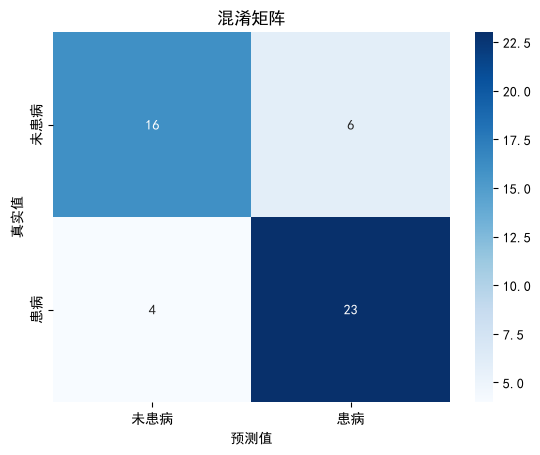

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.rcParams['font.sans-serif']='SimHei'#解决中文乱码问题
plt.rcParams['axes.unicode_minus']=False#解决负号无法正常显示的问题

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['未患病', '患病'], 
            yticklabels=['未患病', '患病'])
plt.xlabel('预测值')
plt.ylabel('真实值')
plt.title('混淆矩阵')

plt.savefig('output.png', dpi=150, bbox_inches='tight')
plt.show()

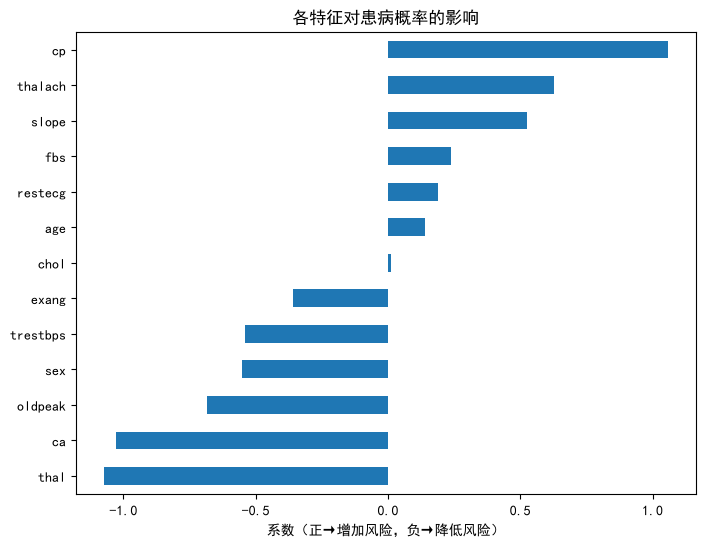

In [3]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
coef.plot(kind='barh', figsize=(8, 6))
plt.title('各特征对患病概率的影响')
plt.xlabel('系数（正→增加风险，负→降低风险）')

plt.savefig('output1.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ========== 随机森林模型（交叉验证调参） ==========
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 定义要搜索的超参数网格
param_grid = {
    'n_estimators': [50, 100, 200],        # 树的个数
    'max_depth': [3, 5, 10, None],          # 树的最大深度
    'min_samples_split': [2, 5, 10],        # 节点再分的最小样本数
    'min_samples_leaf': [1, 2, 4]           # 叶子节点最少样本数
}

# 网格搜索 + 5折交叉验证
rf = RandomForestClassifier(random_state=0)
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid.fit(X_train, y_train)

# 最优参数和最优分数
print('最优参数:', grid.best_params_)
print('交叉验证最优分数:', grid.best_score_)

# 用最优模型预测
rf_best = grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print('【调参后随机森林】测试集评分:', rf_best.score(X_test, y_test))

# 测试集预测
df_test = pd.read_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\heart_test.csv')
X_submit = df_test.drop('ID', axis=1)
predictions_rf = rf_best.predict(X_submit)
result_rf = pd.DataFrame({'ID': df_test['ID'], '预测结果': predictions_rf})
result_rf.to_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\submit_rf.csv', index=False)
print(result_rf)

KeyboardInterrupt: 

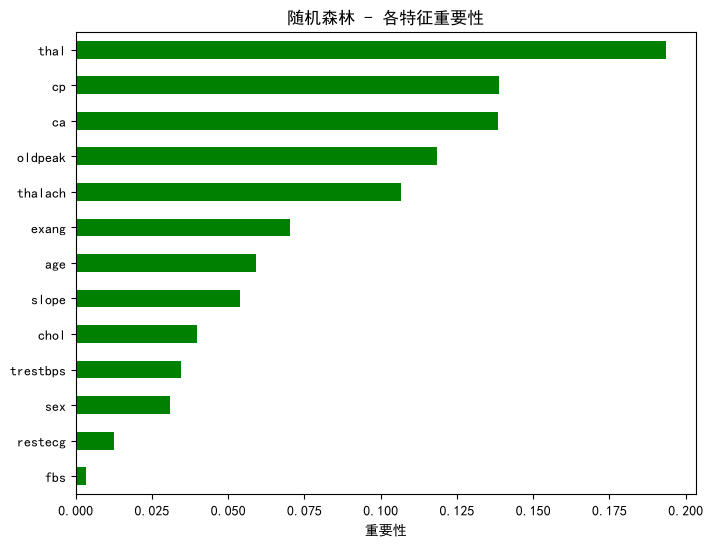

In [ ]:
# 随机森林特征重要性
importance_rf = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values()
importance_rf.plot(kind='barh', figsize=(8, 6), color='green')
plt.title('随机森林 - 各特征重要性')
plt.xlabel('重要性')

plt.savefig('output2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ========== 投票集成模型（逻辑回归 + 随机森林） ==========
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 逻辑回归需要标准化
scaler_vote = StandardScaler()
X_train_scaled = scaler_vote.fit_transform(X_train)
X_test_scaled = scaler_vote.transform(X_test)

# 软投票：用两个模型预测的概率取平均
lr = LogisticRegression(max_iter=1000, random_state=0)
rf = RandomForestClassifier(max_depth=10, min_samples_leaf=4, 
                            min_samples_split=10, n_estimators=100, random_state=0)

voting = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf)],
    voting='soft'  # 用概率投票
)

voting.fit(X_train_scaled, y_train)

y_pred_vote = voting.predict(X_test_scaled)
print('【集成模型】测试集评分:', voting.score(X_test_scaled, y_test))

# 测试集预测
df_test = pd.read_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\heart_test.csv')
X_submit = df_test.drop('ID', axis=1)
X_submit_scaled = scaler_vote.transform(X_submit)

predictions_vote = voting.predict(X_submit_scaled)
result_vote = pd.DataFrame({'ID': df_test['ID'], '预测结果': predictions_vote})
result_vote.to_csv(r'C:\Users\一心一奕\Desktop\实习学习\C3-心脏病甄别\submit_vote.csv', index=False)
print(result_vote)

【集成模型】测试集评分: 0.8163265306122449
    ID  预测结果
0    1     1
1    2     1
2    3     0
3    4     0
4    5     1
..  ..   ...
56  57     1
57  58     1
58  59     0
59  60     1
60  61     0

[61 rows x 2 columns]
